# Thread Implementation Analysis Report

In [88]:
import pandas as pd
import numpy as np
import scipy.stats as stats
import matplotlib.pyplot as plt

def load_oscilloscope_data(filename):
    df = pd.read_csv(filename, skiprows=1, names=["Time (s)", "Voltage (V)"])
    df["Time (s)"] = pd.to_numeric(df["Time (s)"], errors="coerce")
    df["Voltage (V)"] = pd.to_numeric(df["Voltage (V)"].astype(str).str.replace("+", "", regex=False), errors="coerce")
    df = df.dropna()
    return df["Time (s)"].to_numpy(), df["Voltage (V)"].to_numpy()

def detect_pulses(time, voltage, threshold=1.5, invert=False):
    if invert:
        binary_signal = (voltage < threshold).astype(int)
    else:
        binary_signal = (voltage > threshold).astype(int)
    
    rising_edges = np.where(np.diff(binary_signal) > 0)[0]
    falling_edges = np.where(np.diff(binary_signal) < 0)[0]
    
    rising_times = time[rising_edges]
    falling_times = time[falling_edges]
    
    return rising_times, falling_times

def calculate_duty_cycles(rising_times, falling_times):
    duty_cycles = []
    pulse_widths = []
    periods = []

    if len(rising_times) < 2:
        return np.array([]), np.array([]), np.array([])
    
    for i in range(len(rising_times) - 1):
        rising = rising_times[i]
        
        falling_after = falling_times[falling_times > rising]
        if len(falling_after) == 0:
            continue
        falling = falling_after[0]

        pulse_width = falling - rising
        
        period = rising_times[i + 1] - rising
        
        duty_cycle = (pulse_width / period) * 100
        
        duty_cycles.append(duty_cycle)
        pulse_widths.append(pulse_width)
        periods.append(period)
    
    return np.array(duty_cycles), np.array(pulse_widths), np.array(periods)

def calculate_statistics(data, confidence=0.95):
    if len(data) == 0:
        return None
    
    mean = np.mean(data)
    std = np.std(data, ddof=1)
    sem = stats.sem(data)
    
    ci = stats.t.interval(confidence, len(data)-1, loc=mean, scale=sem)
    ci_range = ci[1] - mean
    
    return {
        'mean': mean,
        'std': std,
        'sem': sem,
        'ci_lower': ci[0],
        'ci_upper': ci[1],
        'ci_range': ci_range,
        'n_samples': len(data)
    }

def analyze_duty_cycle(filename, nominal_duty=10.0, nominal_freq=1.0, threshold=1.5, invert=False):
    time, voltage = load_oscilloscope_data(filename)
    print(f"Voltage range: {voltage.min():.3f} to {voltage.max():.3f} V")
    print(f"Threshold: {threshold} V")

    rising_times, falling_times = detect_pulses(time, voltage, threshold, invert)
    
    duty_cycles, pulse_widths, periods = calculate_duty_cycles(rising_times, falling_times)

    
    if len(duty_cycles) == 0:
        print("ERROR: No complete pulses detected!")
        return None
    
    duty_stats = calculate_statistics(duty_cycles)
    width_stats = calculate_statistics(pulse_widths)
    period_stats = calculate_statistics(periods)
    
    frequencies = 1.0 / periods
    freq_stats = calculate_statistics(frequencies)
    
    print(f"\nDUTY CYCLE:")
    print(f"   Mean: {duty_stats['mean']:.3f}%")
    print(f"   Std Dev: {duty_stats['std']:.3f}%")
    print(f"   95% CI: [{duty_stats['ci_lower']:.3f}%, {duty_stats['ci_upper']:.3f}%]")
    print(f"   Nominal: {nominal_duty:.3f}%")
    print(f"   Error: {duty_stats['mean'] - nominal_duty:.3f}% ({((duty_stats['mean'] - nominal_duty)/nominal_duty)*100:.2f}% relative error)")
    
    print(f"\nPULSE WIDTH (HIGH time):")
    print(f"   Mean: {width_stats['mean']*1000:.3f} ms")
    print(f"   Std Dev: {width_stats['std']*1000:.3f} ms")
    print(f"   Expected (10% of 1s): {nominal_duty/100 * (1/nominal_freq) * 1000:.3f} ms")
    print(f"\n")
    
    results = {
        'duty_cycles': duty_cycles,
        'pulse_widths': pulse_widths,
        'periods': periods,
        'frequencies': frequencies,
        'duty_stats': duty_stats,
        'width_stats': width_stats,
        'period_stats': period_stats,
        'freq_stats': freq_stats,
        'time': time,
        'voltage': voltage,
        'threshold': threshold
    }
    
    return results

def plot_duty_cycle_results(results, nominal_duty=10.0, nominal_freq=1.0):
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
    
    ax1.hist(results['duty_cycles'], bins=20, color='steelblue', alpha=0.7, edgecolor='black')
    ax1.axvline(nominal_duty, color='red', linestyle='--', linewidth=2.5, 
                label=f'Nominal: {nominal_duty}%')
    ax1.axvline(results['duty_stats']['mean'], color='darkblue', linestyle='-', linewidth=2.5,
                label=f"Mean: {results['duty_stats']['mean']:.2f}%")
    ax1.axvline(results['duty_stats']['ci_lower'], color='orange', linestyle=':', linewidth=2,
                label='95% CI bounds')
    ax1.axvline(results['duty_stats']['ci_upper'], color='orange', linestyle=':', linewidth=2)
    ax1.set_xlabel('Duty Cycle (%)', fontsize=12)
    ax1.set_ylabel('Count', fontsize=12)
    ax1.set_title('Duty Cycle Distribution', fontsize=13, fontweight='bold')
    ax1.legend(fontsize=10)
    ax1.grid(True, alpha=0.3, axis='y')

    deviation = results['duty_stats']['mean'] - nominal_duty
    error = results['duty_stats']['ci_range']
    
    ax2.errorbar(0, deviation, yerr=error, fmt='o', capsize=10, markersize=15, 
                 linewidth=3, color='coral', ecolor='darkred',
                 label=f"Measured: {results['duty_stats']['mean']:.2f}%")
    ax2.axhline(0, color='black', linestyle='--', linewidth=2, 
                label=f'Nominal: {nominal_duty}%')
    ax2.set_xlim(-0.5, 0.5)
    ax2.set_xticks([0])
    ax2.set_xticklabels(['Oscilloscope'])
    ax2.set_ylabel('Duty Cycle Deviation from Nominal (%)', fontsize=12)
    ax2.set_title('Duty Cycle Accuracy with 95% CI', fontsize=13, fontweight='bold')
    ax2.legend(fontsize=11)
    ax2.grid(True, alpha=0.3, axis='y')
    
    fig.suptitle('PWM Duty Cycle Analysis (25% @ 1Hz)', 
                 fontsize=14, fontweight='bold')
    plt.tight_layout()
    
    return fig

def create_summary_table(results, nominal_duty=25.0, nominal_freq=1.0):

    print(f"{'Parameter':<25} {'Measured':<20} {'Nominal':<15} {'Error':<15}")
    print("-" * 70)
    print(f"{'Duty Cycle':<25} {results['duty_stats']['mean']:.3f} ± {results['duty_stats']['ci_range']:.3f}%"
          f"{nominal_duty:>12.3f}%   {results['duty_stats']['mean']-nominal_duty:>10.3f}%")
    print(f"{'Pulse Width':<25} {results['width_stats']['mean']*1000:.3f} ± {results['width_stats']['ci_range']*1000:.3f} ms"
          f"{(nominal_duty/100)*(1/nominal_freq)*1000:>10.3f} ms  {(results['width_stats']['mean']-(nominal_duty/100)*(1/nominal_freq))*1000:>10.3f} ms")
    print(f"{'Frequency':<25} {results['freq_stats']['mean']:.6f} ± {results['freq_stats']['ci_range']:.6f} Hz"
          f"{nominal_freq:>10.6f} Hz {results['freq_stats']['mean']-nominal_freq:>10.6f} Hz")
    print(f"{'Period':<25} {results['period_stats']['mean']:.6f} ± {results['period_stats']['ci_range']:.6f} s"
          f"{1/nominal_freq:>10.6f} s  {results['period_stats']['mean']-(1/nominal_freq):>10.6f} s")

# ADC Single Sampling (PART 1)

## Methods

For this part of the ADC lab we were tasked with reading in input from the AIN0 channel of the ADC and map the input voltage reading to a blink frequency. The equation that I used to map the voltage to the frequency is freq  = 1.0 + ((mV * 4.0) / 3000.0) which should result in a perferct linear relationship (R^2 = 0) of the frequency and input voltage. Slight variations from this mapping can be due to noise, resolution limits, and/or timing. The function generator was used to test different input voltages and the oscilliscope was used to measure the frequency the blink rate. I measured various voltages, 0.0 0.5 1.0 1.5 2.0 2.5 and 3.0 V, all at 0.15A, 3 different times to perform robust testing get more accurate results and mitigate error. The oscilliscope was set to a 50,000 sampling at 5k samples per second rate. Once the voltage was mapped to the frequency, the LED would blink for 5 seconds at the mapped frequency and if an error occured, it was logged and the device went to the error state.

Voltage: 0V
  Mean Frequency: 1.000 Hz
  Std Dev: 0.000 Hz
  N cycles: 4

Voltage: 0.5V
  Mean Frequency: 1.664 Hz
  Std Dev: 0.000 Hz
  N cycles: 8

Voltage: 1V
  Mean Frequency: 2.336 Hz
  Std Dev: 0.001 Hz
  N cycles: 11

Voltage: 1.5V
  Mean Frequency: 3.021 Hz
  Std Dev: 0.073 Hz
  N cycles: 15

Voltage: 2V
  Mean Frequency: 3.663 Hz
  Std Dev: 0.002 Hz
  N cycles: 18

Voltage: 2.5V
  Mean Frequency: 4.329 Hz
  Std Dev: 0.002 Hz
  N cycles: 21

Voltage: 3V
  Mean Frequency: 4.999 Hz
  Std Dev: 0.003 Hz
  N cycles: 24


Summary Statistics:
   Input_Voltage_V  Mean_Frequency_Hz  Std_Frequency_Hz  SEM_Frequency_Hz  \
0              0.0           1.000000          0.000163          0.000082   
1              0.5           1.663721          0.000489          0.000173   
2              1.0           2.336201          0.000822          0.000248   
3              1.5           3.021442          0.072684          0.018767   
4              2.0           3.662856          0.001946          

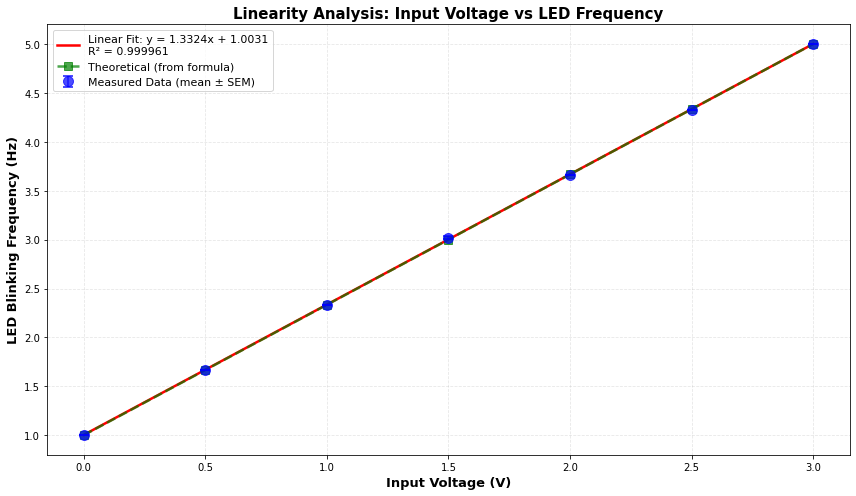

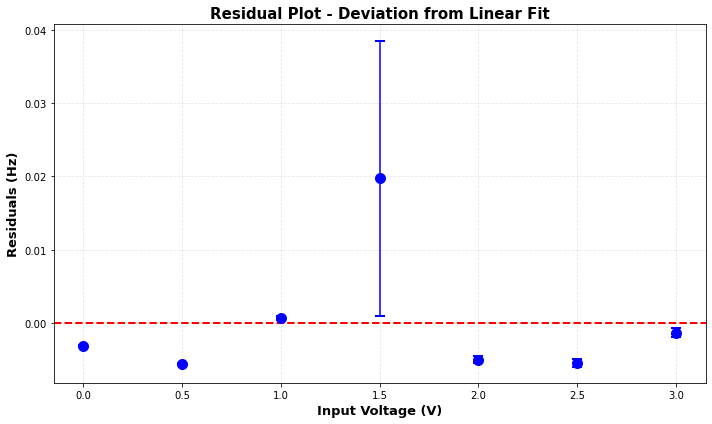


Residuals Analysis:
Mean Residual: 0.000000 Hz
Std Dev of Residuals: 0.008349 Hz


In [89]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import scipy as sp
from scipy import signal

def calculate_frequency_from_voltage_trace(csv_file, threshold=1.5):
    """
    Calculate the blinking frequency from voltage trace data.
    
    Parameters:
    csv_file (str): Path to CSV file with time and voltage data
    threshold (float): Voltage threshold to detect HIGH/LOW transitions (V)
    
    Returns:
    frequencies (list): List of frequencies from each cycle
    mean_freq (float): Mean frequency over the measurement period
    """
    # Read the CSV file, skipping the header rows
    df = pd.read_csv(csv_file, skiprows=2, names=['time_s', 'voltage_V'])
    
    # Remove any rows with missing data
    df = df.dropna()
    
    # Convert to numeric (in case of formatting issues)
    df['time_s'] = pd.to_numeric(df['time_s'])
    df['voltage_V'] = pd.to_numeric(df['voltage_V'])
    
    # Create binary signal: 1 for HIGH, 0 for LOW
    binary_signal = (df['voltage_V'] > threshold).astype(int)
    
    # Find rising edges (transitions from LOW to HIGH)
    rising_edges = np.where(np.diff(binary_signal) == 1)[0]
    
    # Calculate time at each rising edge
    rising_edge_times = df['time_s'].iloc[rising_edges].values
    
    # Calculate periods (time between consecutive rising edges)
    if len(rising_edge_times) > 1:
        periods = np.diff(rising_edge_times)
        frequencies = 1.0 / periods  # frequency = 1 / period
        mean_freq = np.mean(frequencies)
    else:
        frequencies = []
        mean_freq = 0
    
    return frequencies, mean_freq

# Alternatively, use FFT for more robust frequency estimation
def calculate_frequency_fft(csv_file, threshold=1.5):
    """
    Calculate frequency using FFT of the voltage trace.
    """
    df = pd.read_csv(csv_file, skiprows=2, names=['time_s', 'voltage_V'])
    df = df.dropna()
    df['time_s'] = pd.to_numeric(df['time_s'])
    df['voltage_V'] = pd.to_numeric(df['voltage_V'])
    
    # Create binary signal
    binary_signal = (df['voltage_V'] > threshold).astype(int)
    
    # Calculate sampling rate
    dt = np.mean(np.diff(df['time_s']))
    sampling_rate = 1.0 / dt
    
    # Compute FFT
    fft = np.fft.fft(binary_signal)
    freqs = np.fft.fftfreq(len(binary_signal), dt)
    
    # Get positive frequencies only
    positive_freqs = freqs[:len(freqs)//2]
    positive_fft = np.abs(fft[:len(fft)//2])
    
    # Find dominant frequency (excluding DC component)
    dominant_freq_idx = np.argmax(positive_fft[1:]) + 1
    dominant_freq = positive_freqs[dominant_freq_idx]
    
    return dominant_freq

# Define your voltage levels and corresponding data files
voltages = [0, 0.5, 1, 1.5, 2, 2.5, 3]  # Input voltages in V
data_files = {
    0: '0.0V_1.csv',
    0: '0.0V_2.csv',
    0: '0.0V_3.csv',
    0.5: '0.5V_1.csv',
    0.5: '0.5V_2.csv',
    0.5: '0.5V_3.csv',
    1: '1V_1.csv',
    1: '1V_2.csv',
    1: '1V_3.csv',
    1.5: '1.5V_1.csv',
    1.5: '1.5V_2.csv',
    1.5: '1.5V_3.csv',
    2: '2.0V_1.csv',
    2: '2.0V_2.csv',
    2: '2.0V_3.csv',
    2.5: '2.5V_1.csv',
    2.5: '2.5V_2.csv',
    2.5: '2.5V_3.csv',
    3: '3.0V_1.csv',
    3: '3.0V_2.csv',
    3: '3.0V_3.csv'
}

# Step 1: Process each file and collect frequency measurements
data_summary = []

for voltage in voltages:
    # Method 1: Count rising edges
    frequencies, mean_freq = calculate_frequency_from_voltage_trace(data_files[voltage])
    
    # Method 2: FFT (alternative, more robust for noisy signals)
    # mean_freq = calculate_frequency_fft(data_files[voltage])
    
    if len(frequencies) > 0:
        std_freq = np.std(frequencies, ddof=1)
        sem_freq = std_freq / np.sqrt(len(frequencies))
        n_measurements = len(frequencies)
    else:
        std_freq = 0
        sem_freq = 0
        n_measurements = 0
    
    data_summary.append({
        'Input_Voltage_V': voltage,
        'Mean_Frequency_Hz': mean_freq,
        'Std_Frequency_Hz': std_freq,
        'SEM_Frequency_Hz': sem_freq,
        'N_Measurements': n_measurements
    })
    
    print(f"Voltage: {voltage}V")
    print(f"  Mean Frequency: {mean_freq:.3f} Hz")
    print(f"  Std Dev: {std_freq:.3f} Hz")
    print(f"  N cycles: {n_measurements}")
    print()

# Step 2: Create DataFrame
df = pd.DataFrame(data_summary)
print("\nSummary Statistics:")
print(df)

# Step 3: Perform linear regression
slope, intercept, r_value, p_value, std_err = sp.stats.linregress(
    df['Input_Voltage_V'], 
    df['Mean_Frequency_Hz']
)

r_squared = r_value**2

print(f"\nLinear Regression Results:")
print(f"Slope: {slope:.4f} Hz/V")
print(f"Intercept: {intercept:.4f} Hz")
print(f"R²: {r_squared:.6f}")
print(f"p-value: {p_value:.6e}")

# Step 4: Calculate theoretical values from your formula
# freq = 1 + (adc_read_mv * 4) / 3000
# Need to determine the relationship between input voltage and adc_read_mv
# If you have a voltage divider or direct connection, adjust accordingly
# Example: if 3V input → 3000mV at ADC (1:1 ratio)
theoretical_voltages = np.array(voltages)
adc_read_mv = theoretical_voltages * 1000  # Convert V to mV (adjust if voltage divider)
theoretical_freq = 1.0 + (adc_read_mv * 4.0) / 3000.0

# Add theoretical values to dataframe
df['Theoretical_Frequency_Hz'] = theoretical_freq

print("\nComparison with Theoretical Values:")
print(df[['Input_Voltage_V', 'Mean_Frequency_Hz', 'Theoretical_Frequency_Hz']])

# Step 5: Plot with error bars
fig, ax = plt.subplots(figsize=(12, 7))

# Plot measured data with error bars
ax.errorbar(df['Input_Voltage_V'], df['Mean_Frequency_Hz'], 
            yerr=df['SEM_Frequency_Hz'],
            fmt='o', markersize=10, capsize=5, capthick=2,
            label='Measured Data (mean ± SEM)', color='blue', alpha=0.7, zorder=3)

# Plot linear regression fit
x_fit = np.linspace(df['Input_Voltage_V'].min(), df['Input_Voltage_V'].max(), 100)
y_fit = slope * x_fit + intercept
ax.plot(x_fit, y_fit, 'r-', linewidth=2.5, 
        label=f'Linear Fit: y = {slope:.4f}x + {intercept:.4f}\nR² = {r_squared:.6f}',
        zorder=2)

# Plot theoretical line
ax.plot(df['Input_Voltage_V'], df['Theoretical_Frequency_Hz'], 
        'g--', linewidth=2.5, marker='s', markersize=8,
        label='Theoretical (from formula)', alpha=0.7, zorder=2)

ax.set_xlabel('Input Voltage (V)', fontsize=13, fontweight='bold')
ax.set_ylabel('LED Blinking Frequency (Hz)', fontsize=13, fontweight='bold')
ax.set_title('Linearity Analysis: Input Voltage vs LED Frequency', fontsize=15, fontweight='bold')
ax.legend(fontsize=11, loc='best')
ax.grid(True, alpha=0.3, linestyle='--')
plt.tight_layout()
plt.show()

# Step 6: Plot residuals
residuals = df['Mean_Frequency_Hz'] - (slope * df['Input_Voltage_V'] + intercept)

fig, ax = plt.subplots(figsize=(10, 6))
ax.errorbar(df['Input_Voltage_V'], residuals, 
            yerr=df['SEM_Frequency_Hz'],
            fmt='o', markersize=10, capsize=5, capthick=2, color='blue')
ax.axhline(y=0, color='r', linestyle='--', linewidth=2)
ax.set_xlabel('Input Voltage (V)', fontsize=13, fontweight='bold')
ax.set_ylabel('Residuals (Hz)', fontsize=13, fontweight='bold')
ax.set_title('Residual Plot - Deviation from Linear Fit', fontsize=15, fontweight='bold')
ax.grid(True, alpha=0.3, linestyle='--')
plt.tight_layout()
plt.show()

print(f"\nResiduals Analysis:")
print(f"Mean Residual: {np.mean(residuals):.6f} Hz")
print(f"Std Dev of Residuals: {np.std(residuals):.6f} Hz")

In [90]:
import pandas as pd
import numpy as np

# List of files to analyze
files = ['0.0V_1.csv', '0.5V_1.csv', '1V_1.csv', '1.5V_1.csv', '2.0V_1.csv', '2.5V_1.csv', '3.0V_1.csv']

print("LED Timing Analysis - Multiple Files")
print("=" * 80)

for filename in files:
    try:
        # Read the CSV file, skipping the header rows
        df = pd.read_csv(filename, skiprows=2, names=['time', 'voltage'])
        
        # Remove any rows with missing data
        df = df.dropna()
        
        # Convert to numeric
        df['time'] = pd.to_numeric(df['time'])
        df['voltage'] = pd.to_numeric(df['voltage'])
        
        # Determine threshold (midpoint between high and low voltages)
        v_min = df['voltage'].min()
        v_max = df['voltage'].max()
        threshold = (v_min + v_max) / 2
        
        # Create binary signal (1 = LED on, 0 = LED off)
        led_state = (df['voltage'] > threshold).astype(int)
        
        # Detect state transitions
        transitions = np.diff(led_state, prepend=led_state.iloc[0])
        rising_edges = np.where(transitions == 1)[0]   # LED turns on
        falling_edges = np.where(transitions == -1)[0]  # LED turns off
        
        # Calculate on-times and off-times
        on_times = []
        off_times = []
        periods = []
        
        for i in range(len(rising_edges)):
            # Find the next falling edge after this rising edge
            next_falling = falling_edges[falling_edges > rising_edges[i]]
            if len(next_falling) > 0:
                falling_idx = next_falling[0]
                on_time = df['time'].iloc[falling_idx] - df['time'].iloc[rising_edges[i]]
                on_times.append(on_time)
                
                # Find the next rising edge after this falling edge for off-time
                next_rising = rising_edges[rising_edges > falling_idx]
                if len(next_rising) > 0:
                    next_rising_idx = next_rising[0]
                    off_time = df['time'].iloc[next_rising_idx] - df['time'].iloc[falling_idx]
                    off_times.append(off_time)
                    
                    # Period: from this rising edge to next rising edge
                    period = df['time'].iloc[next_rising_idx] - df['time'].iloc[rising_edges[i]]
                    periods.append(period)
        
        # Calculate statistics
        if on_times and off_times and periods:
            avg_on_time = np.mean(on_times)
            avg_off_time = np.mean(off_times)
            avg_period = np.mean(periods)
            duty_cycle = avg_on_time / avg_period * 100
            frequency = 1 / avg_period
            
            print(f"\nFile: {filename}")
            print(f"  Voltage range: {v_min:.3f}V to {v_max:.3f}V")
            print(f"  Average ON time:    {avg_on_time*1000:.3f} ms")
            print(f"  Average OFF time:   {avg_off_time*1000:.3f} ms")
            print(f"  Average Period:     {avg_period*1000:.3f} ms")
            print(f"  Duty Cycle:         {duty_cycle:.2f}%")
            print(f"  Frequency:          {frequency:.3f} Hz")
            print(f"  Complete cycles:    {len(periods)}")
        else:
            print(f"\nFile: {filename}")
            print(f"  ERROR: Could not detect complete cycles")
            
    except FileNotFoundError:
        print(f"\nFile: {filename}")
        print(f"  ERROR: File not found")
    except Exception as e:
        print(f"\nFile: {filename}")
        print(f"  ERROR: {str(e)}")

print("\n" + "=" * 80)

LED Timing Analysis - Multiple Files

File: 0.0V_1.csv
  Voltage range: 0.397V to 3.085V
  Average ON time:    900.000 ms
  Average OFF time:   100.000 ms
  Average Period:     1000.000 ms
  Duty Cycle:         90.00%
  Frequency:          1.000 Hz
  Complete cycles:    4

File: 0.5V_1.csv
  Voltage range: 0.402V to 3.095V
  Average ON time:    542.500 ms
  Average OFF time:   60.625 ms
  Average Period:     603.125 ms
  Duty Cycle:         89.95%
  Frequency:          1.658 Hz
  Complete cycles:    8

File: 1V_1.csv
  Voltage range: 0.362V to 3.095V
  Average ON time:    387.000 ms
  Average OFF time:   43.091 ms
  Average Period:     430.091 ms
  Duty Cycle:         89.98%
  Frequency:          2.325 Hz
  Complete cycles:    11

File: 1.5V_1.csv
  Voltage range: 0.382V to 3.095V
  Average ON time:    299.967 ms
  Average OFF time:   31.167 ms
  Average Period:     331.133 ms
  Duty Cycle:         90.59%
  Frequency:          3.020 Hz
  Complete cycles:    15

File: 2.0V_1.csv
  Volta

## LOG Output

### 0.0 V
ADC reading (mV): 0.000000
Mapped frequency (Hz): 1.000000
Starting LED blink timers: ON time (ms): 100.000000, OFF time (ms): 900.000000

ADC reading (mV): 0.000000
Mapped frequency (Hz): 1.000000
Starting LED blink timers: ON time (ms): 100.000000, OFF time (ms): 900.000000

ADC reading (mV): 0.000000
Mapped frequency (Hz): 1.000000
Starting LED blink timers: ON time (ms): 100.000000, OFF time (ms): 900.000000

### 0.5 V
ADC reading (mV): 491.000000
Mapped frequency (Hz): 1.654667
Starting LED blink timers: ON time (ms): 60.435131, OFF time (ms): 543.916199

ADC reading (mV): 489.000000
Mapped frequency (Hz): 1.652000
Starting LED blink timers: ON time (ms): 60.532692, OFF time (ms): 544.794189

ADC reading (mV): 497.000000
Mapped frequency (Hz): 1.662667
Starting LED blink timers: ON time (ms): 60.144348, OFF time (ms): 541.299133

### 1 V 
ADC reading (mV): 994.000000
Mapped frequency (Hz): 2.325333
Starting LED blink timers: ON time (ms): 43.004585, OFF time (ms): 387.041290

ADC reading (mV): 998.000000
Mapped frequency (Hz): 2.330667
Starting LED blink timers: ON time (ms): 42.906181, OFF time (ms): 386.155609

ADC reading (mV): 996.000000
Mapped frequency (Hz): 2.328000
Starting LED blink timers: ON time (ms): 42.955326, OFF time (ms): 386.597931

### 1.5V
ADC reading (mV): 1494.000000
Mapped frequency (Hz): 2.992000
Starting LED blink timers: ON time (ms): 33.422459, OFF time (ms): 300.802124

ADC reading (mV): 1498.000000
Mapped frequency (Hz): 2.997333
Starting LED blink timers: ON time (ms): 33.362991, OFF time (ms): 300.266907

ADC reading (mV): 1495.000000
Mapped frequency (Hz): 2.993333
Starting LED blink timers: ON time (ms): 33.407570, OFF time (ms): 300.668152

### 2V
ADC reading (mV): 1994.000000
Mapped frequency (Hz): 3.658667
Starting LED blink timers: ON time (ms): 27.332361, OFF time (ms): 245.991241

ADC reading (mV): 1998.000000
Mapped frequency (Hz): 3.664000
Starting LED blink timers: ON time (ms): 27.292576, OFF time (ms): 245.633179

ADC reading (mV): 1993.000000
Mapped frequency (Hz): 3.657333
Starting LED blink timers: ON time (ms): 27.342325, OFF time (ms): 246.080917

### 2.5V 
ADC reading (mV): 2497.000000
Mapped frequency (Hz): 4.329333
Starting LED blink timers: ON time (ms): 23.098246, OFF time (ms): 207.884201

ADC reading (mV): 2496.000000
Mapped frequency (Hz): 4.328000
Starting LED blink timers: ON time (ms): 23.105360, OFF time (ms): 207.948242

ADC reading (mV): 2493.000000
Mapped frequency (Hz): 4.324000
Starting LED blink timers: ON time (ms): 23.126736, OFF time (ms): 208.140610

### 3V
ADC reading (mV): 2998.000000
Mapped frequency (Hz): 4.997334
Starting LED blink timers: ON time (ms): 20.010672, OFF time (ms): 180.096054

ADC reading (mV): 2994.000000
Mapped frequency (Hz): 4.992000
Starting LED blink timers: ON time (ms): 20.032051, OFF time (ms): 180.288452

ADC reading (mV): 2995.000000
Mapped frequency (Hz): 4.993333
Starting LED blink timers: ON time (ms): 20.026703, OFF time (ms): 180.240326


## 5 Second Timer Validation

#### Code in duration_timer_interval_expiry_handler
    
    int64_t current_tick = k_uptime_ticks();
    s_obj.time1_duration_timer = s_obj.time2_duration_timer;
    s_obj.time2_duration_timer = k_ticks_to_ns_near64(current_tick);

    int64_t duration_ns = s_obj.time2_duration_timer - s_obj.time1_duration_timer;

    LOG_INF("5 Second Duration Timer time = %lld ns", duration_ns);
    LOG_INF("5 Second Duration Timer time = %lld s", duration_ns / 1000000000);

#### 1 Hz

[00:00:33.706,481] <dbg> main: adc_read_run: Raw ADC Buffer: 673<br>
[00:00:33.706,481] <inf> main: ADC Value (mV): 492<br>
[00:00:33.706,542] <inf> main: ADC reading (mV): 492<br>
[00:00:33.706,542] <inf> main: Mapped frequency (Hz): 1<br>
[00:00:33.706,542] <inf> main: Starting LED blink timers: ON time (ms): 100, OFF time (ms): 900<br>
[00:00:33.706,573] <inf> main: Starting duration timer for 5 seconds.<br>
[00:00:38.706,665] <inf> main: 5 Second Duration Timer time = 5000000000 ns<br>
[00:00:38.706,695] <inf> main: 5 Second Duration Timer time = 5 s<br>

#### 2 Hz

[00:01:10.060,241] <dbg> main: adc_read_run: Raw ADC Buffer: 1079<br>
[00:01:10.060,241] <inf> main: ADC Value (mV): 790<br>
[00:01:10.060,302] <inf> main: ADC reading (mV): 790<br>
[00:01:10.060,302] <inf> main: Mapped frequency (Hz): 2<br>
[00:01:10.060,302] <inf> main: Starting LED blink timers: ON time (ms): 50, OFF time (ms): 450<br>
[00:01:10.060,333] <inf> main: Starting duration timer for 5 seconds.<br>
[00:01:15.060,424] <inf> main: 5 Second Duration Timer time = 5000000000 ns<br>
[00:01:15.060,455] <inf> main: 5 Second Duration Timer time = 5 s<br>

#### 3 Hz

[00:01:26.563,201] <dbg> main: adc_read_run: Raw ADC Buffer: 2043<br>
[00:01:26.563,201] <inf> main: ADC Value (mV): 1496<br>
[00:01:26.563,262] <inf> main: ADC reading (mV): 1496<br>
[00:01:26.563,262] <inf> main: Mapped frequency (Hz): 3<br>
[00:01:26.563,262] <inf> main: Starting LED blink timers: ON time (ms): 33, OFF time (ms): 300<br>
[00:01:26.563,293] <inf> main: Starting duration timer for 5 seconds.<br>
[00:01:31.563,354] <inf> main: 5 Second Duration Timer time = 5000000000 ns<br>
[00:01:31.563,385] <inf> main: 5 Second Duration Timer time = 5 s<br>

#### 4 Hz

[00:01:46.726,165] <dbg> main: adc_read_run: Raw ADC Buffer: 3000<br>
[00:01:46.726,165] <inf> main: ADC Value (mV): 2197<br>
[00:01:46.726,226] <inf> main: ADC reading (mV): 2197<br>
[00:01:46.726,226] <inf> main: Mapped frequency (Hz): 4<br>
[00:01:46.726,226] <inf> main: Starting LED blink timers: ON time (ms): 25, OFF time (ms): 225<br>
[00:01:46.726,257] <inf> main: Starting duration timer for 5 seconds.<br>
[00:01:51.726,348] <inf> main: 5 Second Duration Timer time = 5000000000 ns<br>
[00:01:51.726,379] <inf> main: 5 Second Duration Timer time = 5 s<br>

#### 5 Hz

[00:02:03.575,531] <dbg> main: adc_read_run: Raw ADC Buffer: 4095<br>
[00:02:03.575,531] <inf> main: ADC Value (mV): 2999<br>
[00:02:03.575,592] <inf> main: ADC reading (mV): 2999<br>
[00:02:03.575,592] <inf> main: Mapped frequency (Hz): 5<br>
[00:02:03.575,592] <inf> main: Starting LED blink timers: ON time (ms): 20, OFF time (ms): 180<br>
[00:02:03.575,622] <inf> main: Starting duration timer for 5 seconds.<br>
[00:02:08.575,683] <inf> main: 5 Second Duration Timer time = 5000000000 ns<br>
[00:02:08.575,714] <inf> main: 5 Second Duration Timer time = 5 s<br>

## Discussion

Linear relationship between voltage and blink frequency: <br>
frequency  = (4/3 * Voltage) + 1 = ((4/3000) * mV) + 1 <br>

Errors: <br>
- When performing my measurments I couldnt get my device to blink at 5 Hz frequency even when I set the input voltage at 3 V. I noticed it said it was sending in just under 3 Volts (2.995 - 2.999), which could do due to limits on the machine. I was also able to output the input my device was reading in and I noticed there was some voltage disipation  due to wire resistance between the input voltage and the device. Additonally the generators internal resistance and the loads resistance can form a voltage divider. 

Results: <br>
- The results of each voltage test mapped to the correct frequency for the blinking light. The analysis from the testing shows that the device is very accurate in terms of its duty cycle, with the on and off time of the blinking LED, with an error of max 0.025% on the duty cycle. 
- The measured time for the 5 second timer was 100% accurate, as noticed with the LOG statements. 
- When calculating the error bars for each input voltage, we notice a large standard deviation for 1.5 V at 0.073 Hz. This can be due to variations of the input voltage as mentioned above with the wire disipation and changes in the input voltage being sent into the device.

# Buffered Differential ADC Sampling (Part 2)

## Methods

For this part of the ADC lab we were tasked with reading in input from the AIN1 and AIN2 channel of the ADC. We used the function generator to collect 20 cycles of a 10 Hz sinusoidal signal at 2V peak to peak (2 Vpp). We used the buffer to collect extra samples of the input which stored all the collected data in an array. We obtained this data with the adc_read() call. Lastly we calculated the number of cycles detetced in the input segment and then outputted the HEX ARRAY of the buffered ADC samples to the terminal.

In [91]:
# Duke BME554L Python Module
# Mark Palmeri
#
# This module contains functions for testing purposes in BME554L.

# from typing import List
import pandas as pd
import scipy as sp
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from typing import List, Union

def read_hex_data(file_path: str) -> List[str]:
    """
    Reads hexadecimal data from a file and returns it as a list of strings.

    Parameters:
    file_path (Pathlib.Path): The path to the file containing hexadecimal data.

    Returns:
    List[str]: A list of hexadecimal strings.
    """
    from pathlib import Path
    with open(Path(file_path), 'r') as file:
        raw_data = file.read()

    # get rid of leading/trailing whitespace and split into lines
    data_lines = raw_data.strip().splitlines()

    hex_data = []

    for line in data_lines:
        # split on |, toss the ASCII columns, then split on whitespace
        hex_data_line = line.split('|')[0].split()
        # append to the hex data list
        hex_data.extend(hex_data_line[0:])

    return hex_data

def unwrap_twos_complement(hex_data: List[str]) -> List[str]:
    """
    Unwraps a 12-bit two's complement list from a 16-bit hexadecimal value list.

    Parameters:
    hex_data (List[str]): The hexadecimal data (12-bit, in 16-bit list) to unwrap.

    Returns:
    raw_voltage (List[str]): The unwrapped two's complement integer.
    """

    raw_voltage = []

    for i in range(0, len(hex_data) - 1, 2): # step by 2 to get every 2 bytes (16 bits) 

        # intepret every two bytes as a 16-bit integer
        raw_value = int(hex_data[i+1] + hex_data[i], 16)
        # mask to get the lower 12 bits (resolution of the ADC specified in the devicetree)
        raw_value &= 0x0FFF
        # interpret signed 12-bit integer (2s complement)
        if raw_value >= 0x800:  # 2048 is 1/2 of 4096 (12-bit int range)
            raw_value -= 0x1000 # subtract 4096
        raw_voltage.append(raw_value)

    return raw_voltage

def plot_with_fit(x: pd.Series, y: pd.Series, x_label: str, y_label: str, title: str):

    # Linear regression
    slope, intercept, r_value, p_value, std_err = sp.stats.linregress(x, y)
    line = slope * np.array(x) + intercept

    # Plotting
    plt.figure(figsize=(10, 6))
    ax = sns.lineplot(x=x, y=y, marker='o', label='Data')
    plt.plot(x, line, color='red', label=f'Linear fit: y = {slope:.2f}x + {intercept:.2f}, R² = {r_value**2:.5f}')
    # Adding error bars
    y_err = std_err * np.ones_like(y)
    ax.errorbar(x, y, yerr=y_err, fmt='o', color='blue', alpha=0.5)

    # Labeling the plot
    plt.xlabel(x_label)
    plt.ylabel(y_label)
    plt.title(title)
    plt.legend()
    plt.show()

def calculate_confidence_intervals(
    x: Union[pd.Series, np.ndarray], y: Union[pd.Series, np.ndarray]
) -> tuple:
    """
    Calculate the 95% confidence intervals for the slope and intercept of a linear regression.

    Parameters:
    x (pd.Series or np.ndarray): The independent variable data.
    y (pd.Series or np.ndarray): The dependent variable data.

    Returns:
    tuple: A tuple containing the confidence intervals for the slope and intercept.
    """

    slope, intercept, r_value, p_value, std_err = sp.stats.linregress(x, y)
    n = len(x)
    t_value = sp.stats.t.ppf(0.975, df=n-2)
    slope_confidence_interval = (slope - t_value * std_err, slope + t_value * std_err)
    intercept_confidence_interval = (
        intercept - t_value * std_err * np.sqrt(1/n + np.mean(x)**2 / np.sum((x - np.mean(x))**2)),
        intercept + t_value * std_err * np.sqrt(1/n + np.mean(x)**2 / np.sum((x - np.mean(x))**2))
    )

    return slope_confidence_interval, intercept_confidence_interval

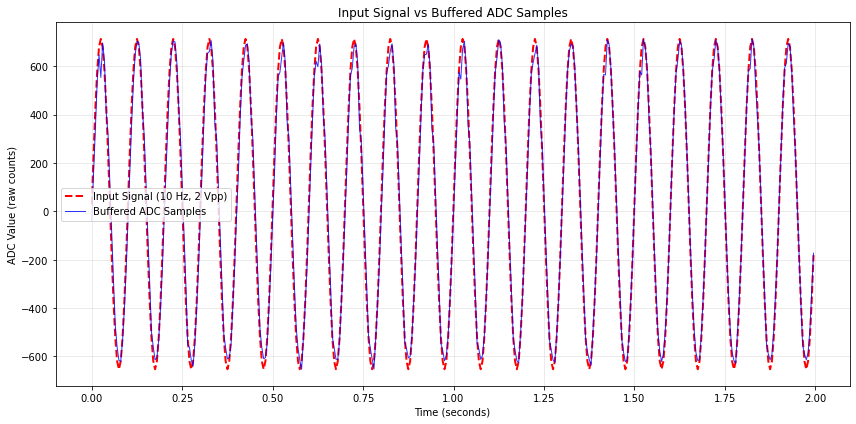

Input Frequency: 10.00 Hz
Measured Frequency: 10.03 Hz
Frequency Error: 0.03 Hz (0.3%)

Number of samples: 400
Sampling rate: 200 Hz
Total time: 2.00 seconds
Detected cycles: 20


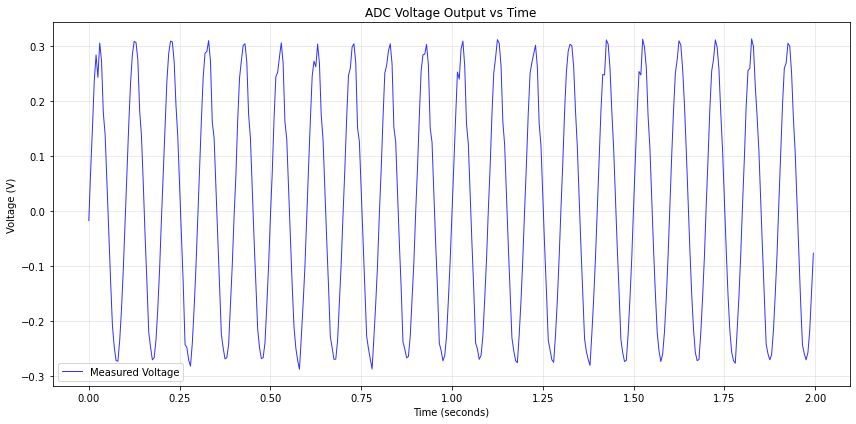


Voltage Statistics:
Peak-to-peak voltage: 0.600 V
Mean voltage: 0.013 V
Min voltage: -0.287 V
Max voltage: 0.313 V


In [92]:
# Import the module
import matplotlib.pyplot as plt
import numpy as np

# Read and convert hex data
hex_data = read_hex_data('part2_hexdump.txt')
raw_adc_values = unwrap_twos_complement(hex_data)

# Time axis (5ms sampling interval = 200 Hz sampling rate)
sampling_rate = 200  # Hz
time = np.arange(len(raw_adc_values)) / sampling_rate

# Generate ideal 10 Hz, 2Vpp sine wave
frequency = 10  # Hz
# Scale ideal sine to match ADC range
adc_amplitude = (max(raw_adc_values) - min(raw_adc_values)) / 2
adc_offset = np.mean(raw_adc_values)
ideal_sine = adc_amplitude * np.sin(2 * np.pi * frequency * time) + adc_offset

# Plot 1: Measured vs Ideal Signal
plt.figure(figsize=(12, 6))
plt.plot(time, ideal_sine, 'r--', linewidth=2, label='Input Signal (10 Hz, 2 Vpp)')
plt.plot(time, raw_adc_values, 'b-', linewidth=1, alpha=0.8, label='Buffered ADC Samples')
plt.xlabel('Time (seconds)')
plt.ylabel('ADC Value (raw counts)')
plt.title('Input Signal vs Buffered ADC Samples')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Calculate frequency using zero-crossing method
midpoint = np.mean(raw_adc_values)
zero_crossings = 0
for i in range(1, len(raw_adc_values)):
    if raw_adc_values[i-1] < midpoint and raw_adc_values[i] >= midpoint:
        zero_crossings += 1

measured_frequency = zero_crossings / time[-1]  # cycles / total_time

# Print results
print(f"Input Frequency: 10.00 Hz")
print(f"Measured Frequency: {measured_frequency:.2f} Hz")
print(f"Frequency Error: {abs(measured_frequency - 10):.2f} Hz ({abs(measured_frequency - 10)/10 * 100:.1f}%)")
print(f"\nNumber of samples: {len(raw_adc_values)}")
print(f"Sampling rate: {sampling_rate} Hz")
print(f"Total time: {time[-1]:.2f} seconds")
print(f"Detected cycles: {zero_crossings}")

# Convert ADC values to volts
# For a 12-bit ADC with reference voltage (typically 3.3V or 1.8V)
vref = 1.8  # Change this to your actual reference voltage (3.3V or 1.8V)
adc_resolution = 2**12  # 4096 for 12-bit ADC

# Convert raw ADC values to voltage
voltage_values = np.array(raw_adc_values) * vref / adc_resolution

# Plot 2: Voltage vs Time
plt.figure(figsize=(12, 6))
plt.plot(time, voltage_values, 'b-', linewidth=1, alpha=0.8, label='Measured Voltage')
plt.xlabel('Time (seconds)')
plt.ylabel('Voltage (V)')
plt.title('ADC Voltage Output vs Time')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Calculate voltage statistics
print(f"\nVoltage Statistics:")
print(f"Peak-to-peak voltage: {np.ptp(voltage_values):.3f} V")
print(f"Mean voltage: {np.mean(voltage_values):.3f} V")
print(f"Min voltage: {np.min(voltage_values):.3f} V")
print(f"Max voltage: {np.max(voltage_values):.3f} V")

## Discussion

One reason that there may be a difference between the input signal and your sampled signal is because of my bit resolution, which is 12 bit resolution. This can cause the sine wave to be rounded to the nearest digital value making it more of a regid sine wave instead of a perfect curve. Another reason can be due to my sampling rate, 20 samples per cycle for 10 Hz, it is hard to capture every point on the sine wave without increasing the sampling rate to a vary large value. Lastly, there can be noise between the input function generator or my device circuitry that causes random errors in the readings. Overall, the results match pretty well, besides a slight phase shift between the obtained and ideal sine wave.

# Asynchronous ADC Sampling (Part 3)

## Methods 

This part of the lab was very similar to part 2 but instead we changed the way in which the data was obtained. Simialr to part 2, we were tasked with reading in input from the AIN1 and AIN2 channel of the ADC. We used the function generator to collect 20 cycles of a 10 Hz sinusoidal signal at 2V peak to peak (2 Vpp). We used the buffer to collect extra samples of the input which stored all the collected data in an array. We obtained this data with the adc_read_async() call. Lastly we calculated the number of cycles detetced in the input segment and then outputted the HEX ARRAY of the buffered ADC samples to the terminal.

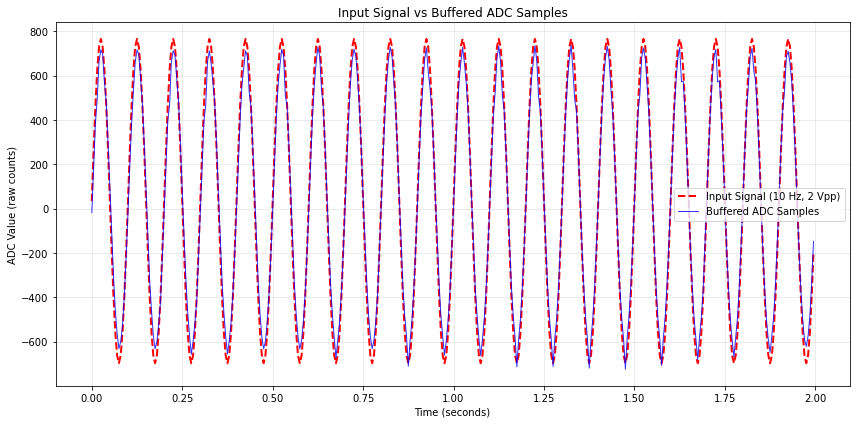

Input Frequency: 10.00 Hz
Measured Frequency: 10.03 Hz
Frequency Error: 0.03 Hz (0.3%)

Number of samples: 400
Sampling rate: 200 Hz
Total time: 2.00 seconds
Detected cycles: 20

Voltage Statistics:
Peak-to-peak voltage: 0.643 V
Mean voltage: 0.015 V
Min voltage: -0.319 V
Max voltage: 0.324 V


In [93]:
# Import the module
import matplotlib.pyplot as plt
import numpy as np

# Read and convert hex data
hex_data = read_hex_data('part3_hexdump.txt')
raw_adc_values = unwrap_twos_complement(hex_data)

# Time axis (5ms sampling interval = 200 Hz sampling rate)
sampling_rate = 200  # Hz
time = np.arange(len(raw_adc_values)) / sampling_rate

# Generate ideal 10 Hz, 2Vpp sine wave
frequency = 10  # Hz
# Scale ideal sine to match ADC range
adc_amplitude = (max(raw_adc_values) - min(raw_adc_values)) / 2
adc_offset = np.mean(raw_adc_values)
ideal_sine = adc_amplitude * np.sin(2 * np.pi * frequency * time) + adc_offset

# Plot 1: Measured vs Ideal Signal
plt.figure(figsize=(12, 6))
plt.plot(time, ideal_sine, 'r--', linewidth=2, label='Input Signal (10 Hz, 2 Vpp)')
plt.plot(time, raw_adc_values, 'b-', linewidth=1, alpha=0.8, label='Buffered ADC Samples')
plt.xlabel('Time (seconds)')
plt.ylabel('ADC Value (raw counts)')
plt.title('Input Signal vs Buffered ADC Samples')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Calculate frequency using zero-crossing method
midpoint = np.mean(raw_adc_values)
zero_crossings = 0
for i in range(1, len(raw_adc_values)):
    if raw_adc_values[i-1] < midpoint and raw_adc_values[i] >= midpoint:
        zero_crossings += 1

measured_frequency = zero_crossings / time[-1]  # cycles / total_time

# Print results
print(f"Input Frequency: 10.00 Hz")
print(f"Measured Frequency: {measured_frequency:.2f} Hz")
print(f"Frequency Error: {abs(measured_frequency - 10):.2f} Hz ({abs(measured_frequency - 10)/10 * 100:.1f}%)")
print(f"\nNumber of samples: {len(raw_adc_values)}")
print(f"Sampling rate: {sampling_rate} Hz")
print(f"Total time: {time[-1]:.2f} seconds")
print(f"Detected cycles: {zero_crossings}")

# Convert ADC values to volts
# For a 12-bit ADC with reference voltage (typically 3.3V or 1.8V)
vref = 1.8  # Change this to your actual reference voltage (3.3V or 1.8V)
adc_resolution = 2**12  # 4096 for 12-bit ADC

# Convert raw ADC values to voltage
voltage_values = np.array(raw_adc_values) * vref / adc_resolution

# Calculate voltage statistics
print(f"\nVoltage Statistics:")
print(f"Peak-to-peak voltage: {np.ptp(voltage_values):.3f} V")
print(f"Mean voltage: {np.mean(voltage_values):.3f} V")
print(f"Min voltage: {np.min(voltage_values):.3f} V")
print(f"Max voltage: {np.max(voltage_values):.3f} V")

[00:10:42.341,339] <inf> main: Midpoint: 33, Cycles: 20
[00:10:42.341,339] <inf> main: Number of cycles detected: 20

## Discussion

Similar to part 2, the results were very accurate, excluding a slight phase shift between the obtained and ideal sine wave. The measured frequency had an error of 0.3% which is very low and we were able to detect 20 samples which is expected with the sampling rate used for measurements. One of the benefits of adc_read_async() is that it is not a blocking call, like adc_read() is which means that kernel thread deos not have to wait for the ADC to complete before continuing. Just like with the adc_read() call timers and interrupts can be used to perform other tasks while the ADC is running. Additionally, the asynchronous call has a callback associated with it which handle the ADC data after each sample is read. This can lead to timing uncertainty since data is handled one at a time once it is collected instead of in a large chunk. Another drawback is the added complexity with the callback, the state management (ADC_ACTION_CONTINUE, ADC_ACTION_REPEAT, ADC_ACTION_FINISH), as well as the interrupt handlers.

# Timer-Based Single Sampling to Array (Part 4)

## Methods

This part of the lab was very similar to part 2 & 3 but instead we changed the way in which the data was obtained. Similar to the previous parts, we were tasked with reading in input from the AIN1 and AIN2 channel of the ADC. We used the function generator to collect 20 cycles of a 10 Hz sinusoidal signal at 2V peak to peak (2 Vpp). We used a kernel timer to do single ADC samples that are sequentially stored in the array that was associated with the ADC sequence in the previous two sections. Lastly we calculated the number of cycles detetced in the input segment and then outputted the HEX ARRAY of the buffered ADC samples to the terminal.

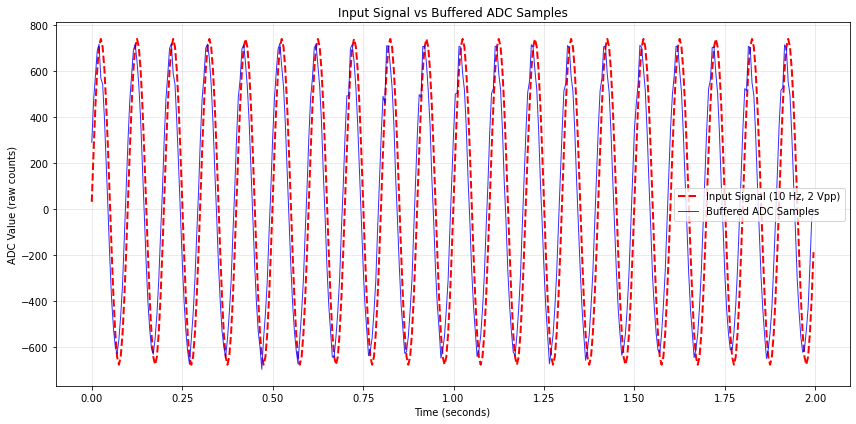

Input Frequency: 10.00 Hz
Measured Frequency: 9.52 Hz
Frequency Error: 0.48 Hz (4.8%)

Number of samples: 400
Sampling rate: 200 Hz
Total time: 2.00 seconds
Detected cycles: 19

Voltage Statistics:
Peak-to-peak voltage: 0.622 V
Mean voltage: 0.014 V
Min voltage: -0.305 V
Max voltage: 0.316 V


In [94]:
# Import the module
import matplotlib.pyplot as plt
import numpy as np

# Read and convert hex data
hex_data = read_hex_data('part4_hexdump.txt')
raw_adc_values = unwrap_twos_complement(hex_data)

# Time axis (5ms sampling interval = 200 Hz sampling rate)
sampling_rate = 200  # Hz
time = np.arange(len(raw_adc_values)) / sampling_rate

# Generate ideal 10 Hz, 2Vpp sine wave
frequency = 10  # Hz
# Scale ideal sine to match ADC range
adc_amplitude = (max(raw_adc_values) - min(raw_adc_values)) / 2
adc_offset = np.mean(raw_adc_values)
ideal_sine = adc_amplitude * np.sin(2 * np.pi * frequency * time) + adc_offset

# Plot 1: Measured vs Ideal Signal
plt.figure(figsize=(12, 6))
plt.plot(time, ideal_sine, 'r--', linewidth=2, label='Input Signal (10 Hz, 2 Vpp)')
plt.plot(time, raw_adc_values, 'b-', linewidth=1, alpha=0.8, label='Buffered ADC Samples')
plt.xlabel('Time (seconds)')
plt.ylabel('ADC Value (raw counts)')
plt.title('Input Signal vs Buffered ADC Samples')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Calculate frequency using zero-crossing method
midpoint = np.mean(raw_adc_values)
zero_crossings = 0
for i in range(1, len(raw_adc_values)):
    if raw_adc_values[i-1] < midpoint and raw_adc_values[i] >= midpoint:
        zero_crossings += 1

measured_frequency = zero_crossings / time[-1]  # cycles / total_time

# Print results
print(f"Input Frequency: 10.00 Hz")
print(f"Measured Frequency: {measured_frequency:.2f} Hz")
print(f"Frequency Error: {abs(measured_frequency - 10):.2f} Hz ({abs(measured_frequency - 10)/10 * 100:.1f}%)")
print(f"\nNumber of samples: {len(raw_adc_values)}")
print(f"Sampling rate: {sampling_rate} Hz")
print(f"Total time: {time[-1]:.2f} seconds")
print(f"Detected cycles: {zero_crossings}")

# Convert ADC values to volts
# For a 12-bit ADC with reference voltage (typically 3.3V or 1.8V)
vref = 1.8  # Change this to your actual reference voltage (3.3V or 1.8V)
adc_resolution = 2**12  # 4096 for 12-bit ADC

# Convert raw ADC values to voltage
voltage_values = np.array(raw_adc_values) * vref / adc_resolution

# Calculate voltage statistics
print(f"\nVoltage Statistics:")
print(f"Peak-to-peak voltage: {np.ptp(voltage_values):.3f} V")
print(f"Mean voltage: {np.mean(voltage_values):.3f} V")
print(f"Min voltage: {np.min(voltage_values):.3f} V")
print(f"Max voltage: {np.max(voltage_values):.3f} V")

[00:00:28.380,126] <inf> main: Midpoint: 31, Cycles: 20<br>
[00:00:28.380,126] <inf> main: Number of cycles detected: 20

## Discussion

One of the drawbacks of using a timer based scheme to obtain the data is that there is a lot of overhead with initalizing the timer and also in the fact that the adc read call can not be handled in the timer expiry handler. There is also a potenial for buffer overflow so we have to increase our buffere size as well as out log message buffer size just in case the logging causes errors. Another error that can occur is the buffer is not ready for the adc read call and the data is not able to be stored properly at the specified rate. Some benefits are that there is deterministic timing because it is kernel based timers and there is no interrupt latencies because the timers execute at the specified intervals. Personally I would choose the asynchronous ADC approach we used in part 3 to get many samples at one time because there is less complexity and overhead. Additionally, I thought part 3 was easier to implement and I got less errors when designing my implementation. 